IMPORT LIBRARIES

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

IMPORT CSV FILE FROM LOCAL

In [6]:
df = pd.read_csv(r"C:\Users\SASWAT\Downloads\customer_shopping_behavior.csv")

CHECK DATA

In [7]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [9]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


check nulls

In [11]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

Review rating gave 37 nan valuees fill with zero

In [12]:
df["Review Rating"] = df["Review Rating"].fillna(0)

In [13]:
##check
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

check duplicate

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["Customer ID"].duplicated().sum()

np.int64(0)

check datatypes

In [16]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                        str
Item Purchased                str
Category                      str
Purchase Amount (USD)       int64
Location                      str
Size                          str
Color                         str
Season                        str
Review Rating             float64
Subscription Status           str
Shipping Type                 str
Discount Applied              str
Promo Code Used               str
Previous Purchases          int64
Payment Method                str
Frequency of Purchases        str
dtype: object

unique value check all string column/categorical column

In [18]:
for col in df.select_dtypes(include='string').columns:
    print(f"\n{col}")
    print(df[col].unique())


Gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Item Purchased
<StringArray>
[    'Blouse',    'Sweater',      'Jeans',    'Sandals',   'Sneakers',
      'Shirt',     'Shorts',       'Coat',    'Handbag',      'Shoes',
      'Dress',      'Skirt', 'Sunglasses',      'Pants',     'Jacket',
     'Hoodie',    'Jewelry',    'T-shirt',      'Scarf',        'Hat',
      'Socks',   'Backpack',       'Belt',      'Boots',     'Gloves']
Length: 25, dtype: str

Category
<StringArray>
['Clothing', 'Footwear', 'Outerwear', 'Accessories']
Length: 4, dtype: str

Location
<StringArray>
[      'Kentucky',          'Maine',  'Massachusetts',   'Rhode Island',
         'Oregon',        'Wyoming',        'Montana',      'Louisiana',
  'West Virginia',       'Missouri',       'Arkansas',         'Hawaii',
       'Delaware',  'New Hampshire',       'New York',        'Alabama',
    'Mississippi', 'North Carolina',     'California',       'Oklahoma',
        'Florida',          'Texas',     

negative value check from all numeric and float column

In [20]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    negative_count = (df[col] < 0).sum()
    zero_count = (df[col] == 0).sum()

    print(f"{col}")
    print(f"Negative Values : {negative_count}")
    print(f"Zero Values     : {zero_count}")
    print("-" * 30)

Customer ID
Negative Values : 0
Zero Values     : 0
------------------------------
Age
Negative Values : 0
Zero Values     : 0
------------------------------
Purchase Amount (USD)
Negative Values : 0
Zero Values     : 0
------------------------------
Review Rating
Negative Values : 0
Zero Values     : 37
------------------------------
Previous Purchases
Negative Values : 0
Zero Values     : 0
------------------------------


# 37 missing values in 'Review Rating' were replaced with 0.
# Here, 0 indicates "No Rating Available" (original missing values).

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

                                                        ANALYSIS PART (EDA)

In [23]:
##DATASET OVERVIEW
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,1950.500000,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,44.068462,15.207589,18.0,31.00,44.0,57.00,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.00,60.0,81.00,100.0
Review Rating,3900.0,3.714487,0.800857,0.0,3.10,3.7,4.40,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.00,25.0,38.00,50.0


Insights:

The dataset contains 3,900 customers with total sales of $233,081 and an average purchase amount of $59.76.
Customer ages range from 18 to 70 years, with an average review rating of 3.71, indicating generally positive customer feedback.

In [25]:
##Correlation Matrix
df.corr(numeric_only=True)

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Customer ID,1.000000,-0.004079,0.011048,0.045399,-0.039159
Age,-0.004079,1.000000,-0.010424,-0.021896,0.040445
Purchase Amount (USD),0.011048,-0.010424,1.000000,0.014276,0.008063
Review Rating,0.045399,-0.021896,0.014276,1.000000,-0.000312
Previous Purchases,-0.039159,0.040445,0.008063,-0.000312,1.000000


Insights:

All correlation values are close to 0, indicating no significant linear relationship among Age, Purchase Amount, Review Rating, and Previous Purchases.
Customer spending appears to be largely independent of age, review ratings, and previous purchases, suggesting other factors may have a greater influence on purchase behavior.

In [56]:
# KPI Dashboard

print("========== KPI DASHBOARD ==========\n")

print("Total Transactions        :", len(df))
print("Total Customers           :", df["Customer ID"].nunique())
print("Total Sales (USD)         :", df["Purchase Amount (USD)"].sum())
print("Average Purchase Amount   :", round(df["Purchase Amount (USD)"].mean(), 2))
print("Maximum Purchase Amount   :", df["Purchase Amount (USD)"].max())
print("Minimum Purchase Amount   :", df["Purchase Amount (USD)"].min())

print("Average Age              :", round(df["Age"].mean(), 2))
print("Youngest Customer Age    :", df["Age"].min())
print("Oldest Customer Age      :", df["Age"].max())

print("Average Review Rating    :", round(df["Review Rating"].mean(), 2))
print("Highest Review Rating    :", df["Review Rating"].max())
print("Lowest Review Rating     :", df["Review Rating"].min())

print("Total Previous Purchases :", df["Previous Purchases"].sum())
print("Average Previous Purchases:", round(df["Previous Purchases"].mean(), 2))

========== KPI DASHBOARD ==========

Total Transactions        : 3900
Total Customers           : 3900
Total Sales (USD)         : 233081
Average Purchase Amount   : 59.76
Maximum Purchase Amount   : 100
Minimum Purchase Amount   : 20
Average Age              : 44.07
Youngest Customer Age    : 18
Oldest Customer Age      : 70
Average Review Rating    : 3.71
Highest Review Rating    : 5.0
Lowest Review Rating     : 0.0
Total Previous Purchases : 98871
Average Previous Purchases: 25.35


SALES BY GENDER

In [27]:
sales_by_gender = df.groupby("Gender")["Purchase Amount (USD)"].sum().sort_values(ascending=False)
print(sales_by_gender)   

Gender
Male      157890
Female     75191
Name: Purchase Amount (USD), dtype: int64


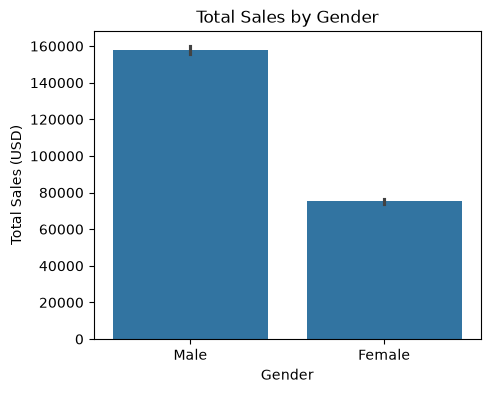

In [28]:
##VISUAL
plt.figure(figsize=(5,4))
sns.barplot(
    data=df,
    x="Gender",
    y="Purchase Amount (USD)",
    estimator="sum"
)
plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales (USD)")
plt.show()

Insights

Male customers generated $157,890 in sales, more than double the $75,191 generated by female customers.
Male customers are the primary contributors to overall revenue in this dataset.

In [33]:
#SALES BY CATEGORY
sales_by_category = (
    df.groupby("Category")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)
print(sales_by_category)

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64


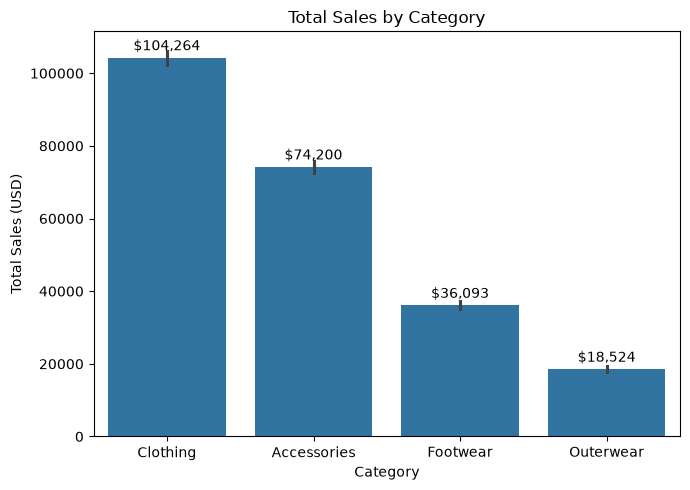

In [45]:
##VISUAL

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=df,
    x="Category",
    y="Purchase Amount (USD)",
    estimator="sum",
    order=sales_by_category.index
)

# Display sales amount on each bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"${v:,.0f}" for v in container.datavalues],
        padding=3,
        fontsize=10
    )

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales (USD)")

plt.tight_layout()
plt.show()

Insights

Clothing is the highest revenue-generating category with $104,264 in sales.
Outerwear recorded the lowest sales, suggesting comparatively lower customer demand.

In [35]:
##Sales by Season
sales_by_season = (
    df.groupby("Season")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
) 
print(sales_by_season)

Season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: Purchase Amount (USD), dtype: int64


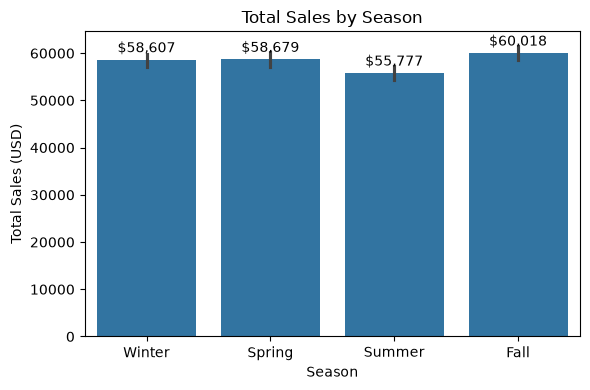

In [44]:
##VISUAL
plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=df,
    x="Season",
    y="Purchase Amount (USD)",
    estimator="sum"
)

# Display sales amount on each bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"${v:,.0f}" for v in container.datavalues],
        padding=3,
        fontsize=10
    )

plt.title("Total Sales by Season")
plt.xlabel("Season")
plt.ylabel("Total Sales (USD)")

plt.tight_layout()
plt.show()

Insights

Fall achieved the highest sales ($60,018), making it the best-performing season.
Sales remain relatively balanced across all seasons, with Summer contributing the lowest revenue.

In [37]:
##Total Sales by Location
sales_by_location = (
    df.groupby("Location")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_location)

Location
Montana           5784
Illinois          5617
California        5605
Idaho             5587
Nevada            5514
Alabama           5261
New York          5257
North Dakota      5220
West Virginia     5174
Nebraska          5172
New Mexico        5014
Minnesota         4977
Pennsylvania      4926
Mississippi       4883
Alaska            4867
Vermont           4860
Louisiana         4848
Virginia          4842
Arkansas          4828
Maryland          4795
Tennessee         4772
Delaware          4758
North Carolina    4742
Texas             4712
Missouri          4691
Indiana           4655
Ohio              4649
Georgia           4645
Washington        4623
Michigan          4533
Utah              4443
South Carolina    4439
Kentucky          4402
Maine             4388
Massachusetts     4384
Oklahoma          4376
Arizona           4326
Wyoming           4309
Oregon            4243
South Dakota      4236
Connecticut       4226
Colorado          4222
New Hampshire     4219
Io

In [38]:
##TOP 10 LOCATION
sales_by_location.head(10)

Location
Montana          5784
Illinois         5617
California       5605
Idaho            5587
Nevada           5514
Alabama          5261
New York         5257
North Dakota     5220
West Virginia    5174
Nebraska         5172
Name: Purchase Amount (USD), dtype: int64

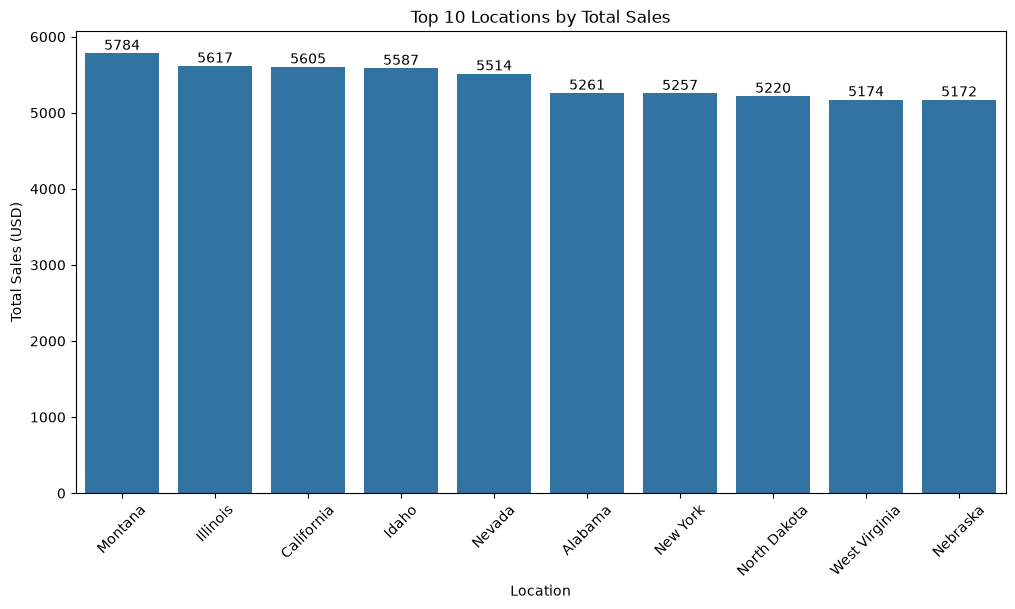

In [40]:
##VISUAL
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=sales_by_location.head(10).index,
    y=sales_by_location.head(10).values
)

# Sales amount on each bar
ax.bar_label(ax.containers[0], fmt='%.0f')

plt.title("Top 10 Locations by Total Sales")
plt.xlabel("Location")
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=45)

plt.show()

Insights

The top 10 locations contribute a significant portion of total sales, led by Montana.
These locations represent high-performing markets and should remain a focus for business growth.

In [47]:
###sales by payment method
payment_summary = (
    df.groupby("Payment Method")["Purchase Amount (USD)"]
      .agg(
          Total_Sales="sum",
          Average_Sales="mean",
          Transactions="count"
      )
      .sort_values(by="Total_Sales", ascending=False)
)

print(payment_summary)


                Total_Sales  Average_Sales  Transactions
Payment Method                                          
Credit Card           40310      60.074516           671
PayPal                40109      59.245199           677
Cash                  40002      59.704478           670
Debit Card            38742      60.915094           636
Venmo                 37374      58.949527           634
Bank Transfer         36544      59.712418           612


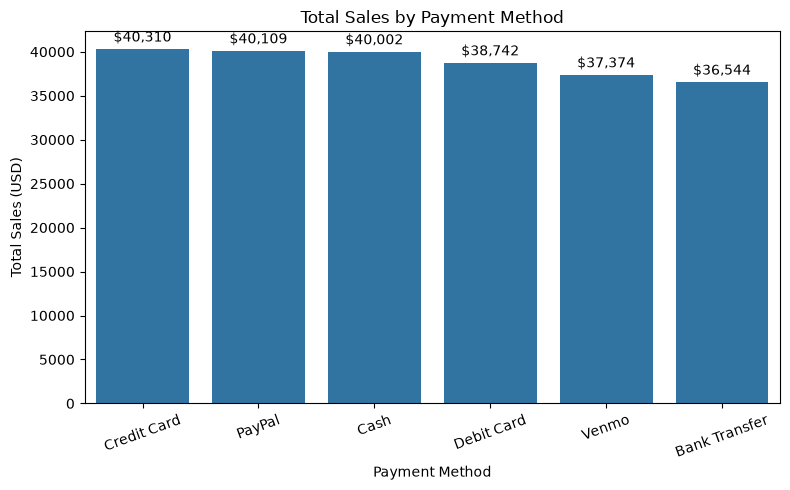

In [48]:
##visual
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=payment_summary.index,
    y=payment_summary["Total_Sales"]
)

# Dollar amount on bars
ax.bar_label(
    ax.containers[0],
    labels=[f"${v:,.0f}" for v in payment_summary["Total_Sales"]],
    padding=3,
    fontsize=10
)

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

Insights

Credit Card generated the highest total sales ($40,310), making it the most valuable payment method.
Bank Transfer contributed the lowest sales, indicating lower customer preference.

In [50]:
##Sales by Shipping Type
sales_by_shipping = (
    df.groupby("Shipping Type")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_shipping)        

Shipping Type
Free Shipping     40777
Express           39067
Store Pickup      38931
Standard          38233
2-Day Shipping    38080
Next Day Air      37993
Name: Purchase Amount (USD), dtype: int64


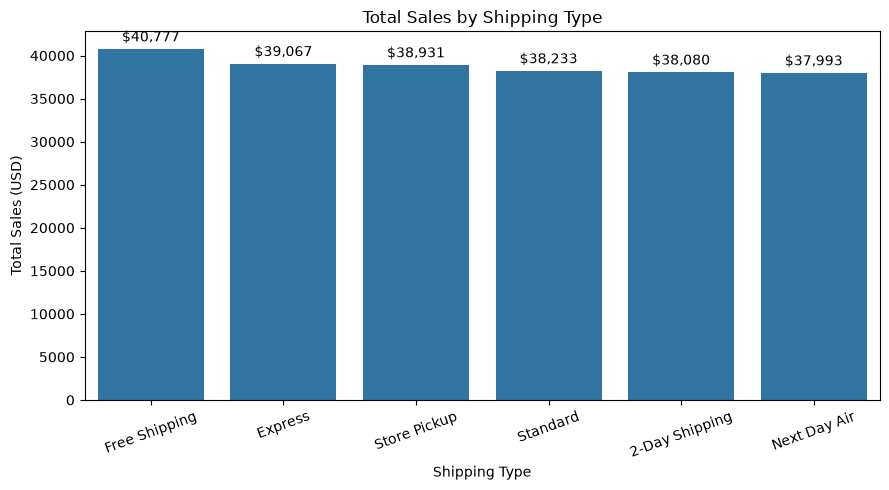

In [52]:
##Visualization   
plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=sales_by_shipping.index,
    y=sales_by_shipping.values
)

# Dollar amount on each bar
ax.bar_label(
    ax.containers[0],
    labels=[f"${v:,.0f}" for v in sales_by_shipping.values],
    padding=3,
    fontsize=10
)

plt.title("Total Sales by Shipping Type")
plt.xlabel("Shipping Type")
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()   

Insights

Free Shipping generated the highest revenue ($40,777), highlighting customers' preference for free delivery.
Sales across shipping methods are relatively balanced, with only moderate differences between options.

In [53]:
##Sales by Subscription Status

sales_by_subscription = (
    df.groupby("Subscription Status")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_subscription)

Subscription Status
No     170436
Yes     62645
Name: Purchase Amount (USD), dtype: int64


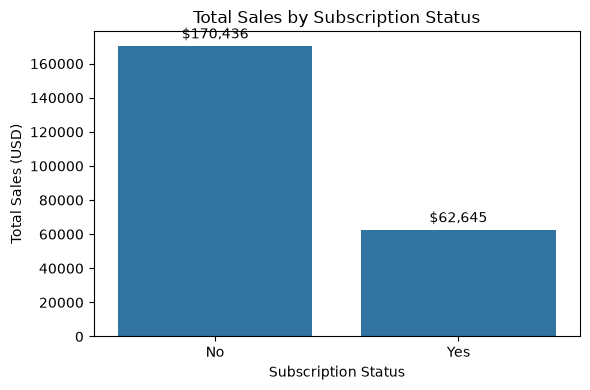

In [55]:
##Visualization
plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=sales_by_subscription.index,
    y=sales_by_subscription.values
)

ax.bar_label(
    ax.containers[0],
    labels=[f"${v:,.0f}" for v in sales_by_subscription.values],
    padding=3,
    fontsize=10
)

plt.title("Total Sales by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Total Sales (USD)")

plt.tight_layout()
plt.show()

Insights

Customers without a subscription generated $170,436, considerably more than subscribed customers ($62,645).
This suggests most revenue currently comes from non-subscribers, presenting an opportunity to grow subscriptions.

In [57]:
# Top 10 Item Purchased
sales_by_item = (
    df.groupby("Item Purchased")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

top10_items = sales_by_item.head(10)

print(top10_items)

Item Purchased
Blouse        10410
Shirt         10332
Dress         10320
Pants         10090
Jewelry       10010
Sunglasses     9649
Belt           9635
Scarf          9561
Sweater        9462
Shorts         9433
Name: Purchase Amount (USD), dtype: int64


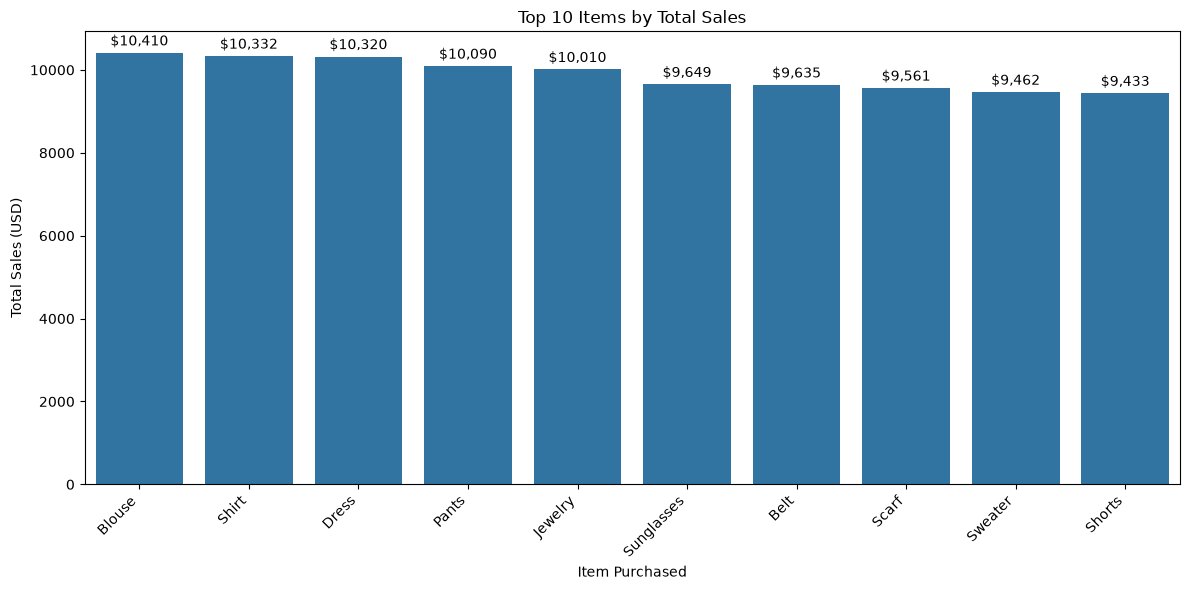

In [58]:
##visual
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top10_items.index,
    y=top10_items.values
)

# Display dollar amount on bars
ax.bar_label(
    ax.containers[0],
    labels=[f"${v:,.0f}" for v in top10_items.values],
    padding=3,
    fontsize=10
)

plt.title("Top 10 Items by Total Sales")
plt.xlabel("Item Purchased")
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Insights

Blouse is the top-selling product with $10,410 in sales, followed closely by Shirt and Dress.
The top-selling items should be prioritized for inventory planning and promotional campaigns.

In [59]:

# Sales by Color

sales_by_color = (
    df.groupby("Color")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_color)

Color
Green        11104
Teal         10459
Yellow       10308
Olive        10292
Cyan         10274
Violet       10245
Gray          9936
Silver        9832
Black         9753
Maroon        9405
Orange        9377
Charcoal      9277
Pink          9270
Purple        9062
White         8895
Beige         8881
Peach         8819
Red           8779
Lavender      8692
Magenta       8684
Blue          8657
Gold          8419
Brown         8328
Indigo        8269
Turquoise     8064
Name: Purchase Amount (USD), dtype: int64


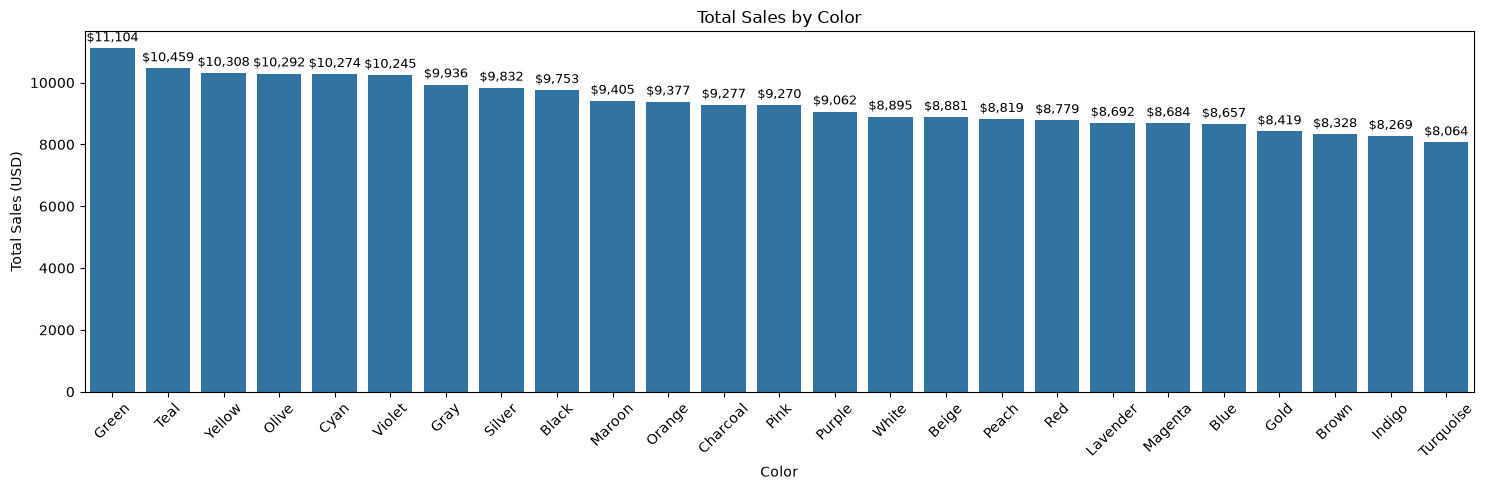

In [62]:
##visual
plt.figure(figsize=(15,5))

ax = sns.barplot(
    x=sales_by_color.index,
    y=sales_by_color.values
)

ax.bar_label(
    ax.containers[0],
    labels=[f"${v:,.0f}" for v in sales_by_color.values],
    padding=3,
    fontsize=9
)

plt.title("Total Sales by Color")
plt.xlabel("Color")
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Insights

Green generated the highest sales ($11,104), making it the most preferred color.
Turquoise recorded the lowest sales, indicating comparatively lower customer preference.

In [63]:
# Sales by Size
sales_by_size = (
    df.groupby("Size")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_size)

Size
M     105167
L      61667
S      40468
XL     25779
Name: Purchase Amount (USD), dtype: int64


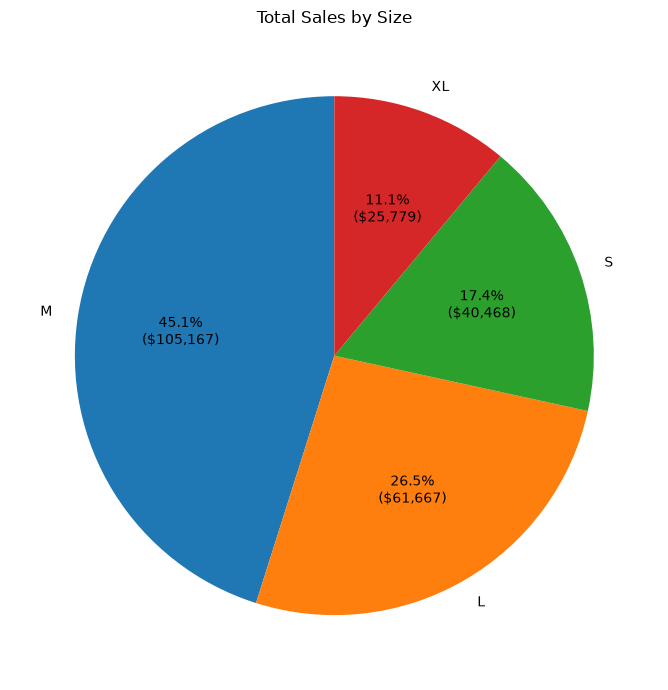

In [64]:
###visual
plt.figure(figsize=(7,7))

plt.pie(
    sales_by_size.values,
    labels=sales_by_size.index,
    autopct=lambda p: f'{p:.1f}%\n(${p*sum(sales_by_size.values)/100:,.0f})',
    startangle=90
)

plt.title("Total Sales by Size")

plt.tight_layout()
plt.show()

Insights

Medium (M) generated the highest sales ($105,167), making it the most demanded size.
Extra Large (XL) contributed the lowest sales among all available sizes.

In [65]:

# Sales by Discount Applied

sales_by_discount = (
    df.groupby("Discount Applied")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_discount)

Discount Applied
No     133670
Yes     99411
Name: Purchase Amount (USD), dtype: int64


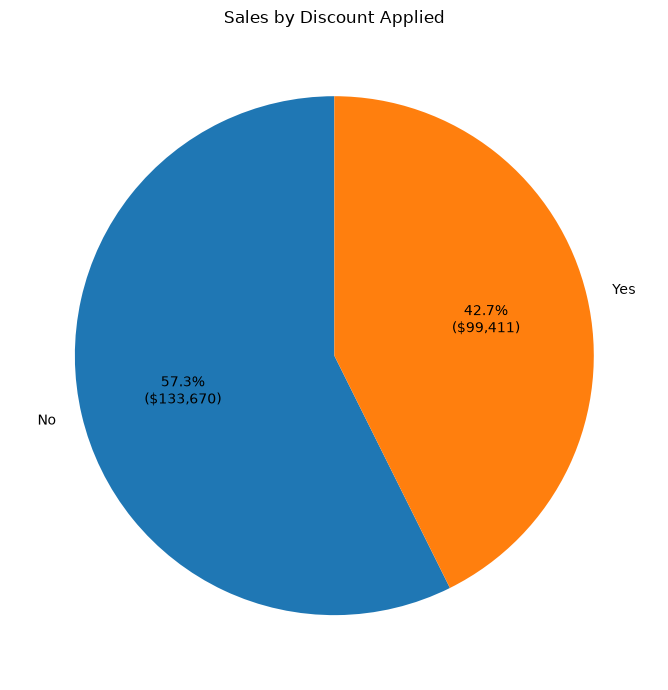

In [67]:
plt.figure(figsize=(7,7))

plt.pie(
    sales_by_discount.values,
    labels=sales_by_discount.index,
    autopct=lambda p: f'{p:.1f}%\n(${p*sum(sales_by_discount.values)/100:,.0f})',
    startangle=90
)

plt.title("Sales by Discount Applied")

plt.tight_layout()
plt.show()

Insights

Sales without discounts ($133,670) exceeded discounted sales ($99,411).
This indicates that many customers purchased products even without promotional discounts.

In [68]:
# ==========================
# Sales by Promo Code Used
# ==========================

sales_by_promo = (
    df.groupby("Promo Code Used")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_promo)

Promo Code Used
No     133670
Yes     99411
Name: Purchase Amount (USD), dtype: int64


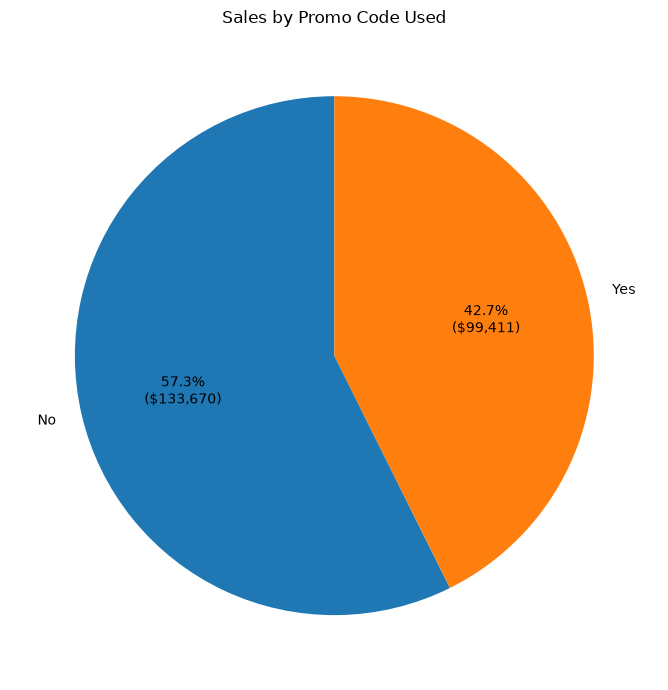

In [69]:
##visual
plt.figure(figsize=(7,7))

plt.pie(
    sales_by_promo.values,
    labels=sales_by_promo.index,
    autopct=lambda p: f'{p:.1f}%\n(${p*sum(sales_by_promo.values)/100:,.0f})',
    startangle=90
)

plt.title("Sales by Promo Code Used")

plt.tight_layout()
plt.show()

Insights

Customers who did not use promo codes generated higher sales than those who used promo codes.
This suggests promo codes were not the primary driver of overall revenue in this dataset.

In [70]:
# ==========================
# Sales by Frequency of Purchases
# ==========================

sales_by_frequency = (
    df.groupby("Frequency of Purchases")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_frequency)

Frequency of Purchases
Every 3 Months    35088
Annually          34419
Quarterly         33771
Bi-Weekly         33200
Monthly           32810
Fortnightly       32007
Weekly            31786
Name: Purchase Amount (USD), dtype: int64


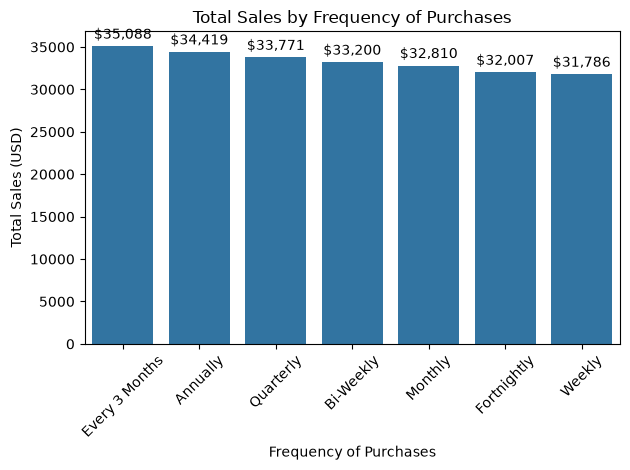

In [71]:
##visualplt.figure(figsize=(10,5))

ax = sns.barplot(
    x=sales_by_frequency.index,
    y=sales_by_frequency.values,
    order=sales_by_frequency.index
)

ax.bar_label(
    ax.containers[0],
    labels=[f"${v:,.0f}" for v in sales_by_frequency.values],
    padding=3,
    fontsize=10
)

plt.title("Total Sales by Frequency of Purchases")
plt.xlabel("Frequency of Purchases")
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Insights

Customers purchasing Every 3 Months generated the highest revenue ($35,088).
Revenue is fairly evenly distributed across purchase frequencies, indicating a balanced customer buying pattern.

CREATE AGE GROUP COLUMN

In [72]:
# ==========================
# Age Group Analysis
# ==========================

bins = [18, 25, 35, 45, 55, 70]
labels = ["18-25", "26-35", "36-45", "46-55", "56-70"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [75]:
##Sales by Age Group
sales_by_age = (
    df.groupby("Age Group")["Purchase Amount (USD)"]
      .sum()  
    .sort_values(ascending=False)
)

print(sales_by_age)

Age Group
56-70    65256
46-55    45619
26-35    44342
36-45    43234
18-25    34630
Name: Purchase Amount (USD), dtype: int64


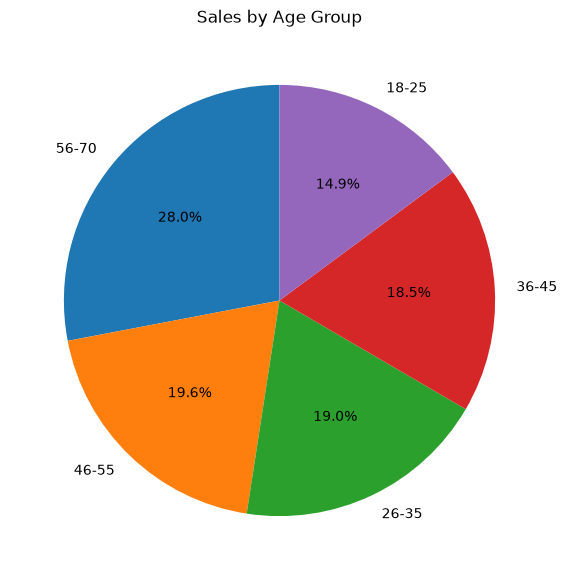

In [76]:
##VISUAL
plt.figure(figsize=(7,7))

plt.pie(
    sales_by_age.values,
    labels=sales_by_age.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sales by Age Group")
plt.show()

In [77]:
##Review Rating Analysis
print(df["Review Rating"].describe())

count    3900.000000
mean        3.714487
std         0.800857
min         0.000000
25%         3.100000
50%         3.700000
75%         4.400000
max         5.000000
Name: Review Rating, dtype: float64


Insights

The average customer review rating is 3.71 out of 5, indicating generally satisfactory customer experiences.
Most review ratings fall between 3.1 and 4.4, showing that customer feedback is largely positive.

In [82]:
##Previous Purchases vs Purchase Amount (USD)
purchase_sales = (
    df.groupby("Previous Purchases")["Purchase Amount (USD)"]
      .mean()
      .sort_values(ascending=False)
)

print(purchase_sales.head(10))

Previous Purchases
8     66.671642
50    65.272727
38    65.142857
5     64.252874
9     63.784615
48    63.588889
47    62.655556
36    62.239437
16    62.157143
33    61.987805
Name: Purchase Amount (USD), dtype: float64


Insights

Customers with 8 previous purchases recorded the highest average purchase amount ($66.67) among the top values shown.
The variation in average purchase amount across previous purchase counts is relatively small, suggesting repeat purchases alone do not strongly increase spending.

In [85]:
# ==========================
# Customer Lifetime Value (CLV)
# ==========================

df["CLV"] = df["Purchase Amount (USD)"] * df["Previous Purchases"]

print(df[["Customer ID",
          "Purchase Amount (USD)",
          "Previous Purchases",
          "CLV"]].head())

   Customer ID  Purchase Amount (USD)  Previous Purchases   CLV
0            1                     53                  14   742
1            2                     64                   2   128
2            3                     73                  23  1679
3            4                     90                  49  4410
4            5                     49                  31  1519


In [86]:
##Top 10 Customers by CLV
top10_clv = (
    df.sort_values(by="CLV", ascending=False)
      [["Customer ID",
        "Purchase Amount (USD)",
        "Previous Purchases",
        "CLV"]]
      .head(10)
)

print(top10_clv)

      Customer ID  Purchase Amount (USD)  Previous Purchases   CLV
455           456                    100                  50  5000
992           993                     99                  50  4950
1847         1848                    100                  49  4900
1737         1738                     98                  50  4900
3746         3747                     99                  49  4851
2271         2272                     99                  49  4851
885           886                     99                  49  4851
2229         2230                     97                  50  4850
2484         2485                     97                  50  4850
2842         2843                    100                  48  4800


In [87]:
##Bottom 10 Customers by CLV
bottom10_clv = (
    df.sort_values(by="CLV")
      [["Customer ID",
        "Purchase Amount (USD)",
        "Previous Purchases",
        "CLV"]]
      .head(10)
)

print(bottom10_clv)

      Customer ID  Purchase Amount (USD)  Previous Purchases  CLV
3142         3143                     21                   1   21
2149         2150                     21                   1   21
1663         1664                     22                   1   22
3332         3333                     23                   1   23
104           105                     24                   1   24
410           411                     26                   1   26
3557         3558                     26                   1   26
2586         2587                     28                   1   28
1971         1972                     29                   1   29
1991         1992                     29                   1   29


In [88]:
##Summary Statistics
print("Average CLV :", round(df["CLV"].mean(),2))
print("Maximum CLV :", df["CLV"].max())
print("Minimum CLV :", df["CLV"].min())

Average CLV : 1517.88
Maximum CLV : 5000
Minimum CLV : 21


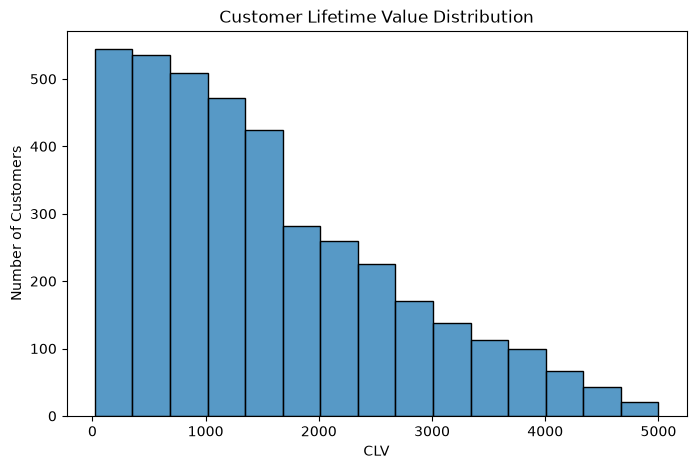

In [89]:
##CLV Distribution (Histogram)
plt.figure(figsize=(8,5))

sns.histplot(df["CLV"], bins=15)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV")
plt.ylabel("Number of Customers")

plt.show()

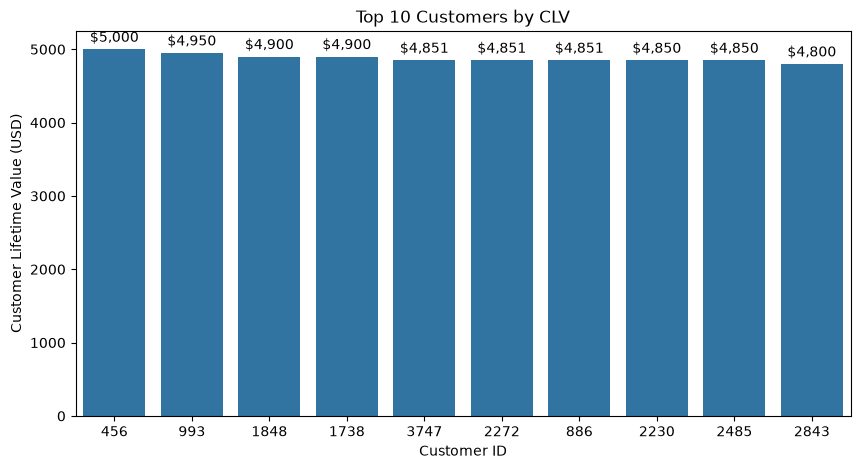

In [90]:
##Top 10 CLV Visualization
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=top10_clv["Customer ID"].astype(str),
    y=top10_clv["CLV"]
)

ax.bar_label(
    ax.containers[0],
    labels=[f"${v:,.0f}" for v in top10_clv["CLV"]],
    padding=3
)

plt.title("Top 10 Customers by CLV")
plt.xlabel("Customer ID")
plt.ylabel("Customer Lifetime Value (USD)")

plt.show()

Insight 1
The average Customer Lifetime Value (CLV) is 1,517.88, while the highest CLV reaches 5,000, indicating that a small group of customers generates significantly higher long-term value.
Insight 2
Top CLV customers combine high purchase amounts ($97–$100) with 48–50 previous purchases, whereas the lowest CLV customers have only one previous purchase and low purchase amounts ($21–$29), highlighting the importance of repeat customers for business growth.

=========================
FINAL CONCLUSION
=========================

• The dataset contains 3,900 customer transactions with total sales of $233,081.

• Clothing is the highest revenue-generating category, while Fall is the best-performing season.

• Male customers contributed more revenue than female customers.

• Montana recorded the highest sales among all locations.

• Medium (M) is the most preferred size, and Green is the highest-selling color.

• Customer spending shows a very weak correlation with Age, Review Rating, and Previous Purchases.

• Customers with high Purchase Amount and high Previous Purchases have the highest Customer Lifetime Value (CLV), making them the most valuable customers.

=========================
BUSINESS RECOMMENDATIONS
=========================

• Increase inventory for top-selling categories and products to avoid stock shortages.

• Focus marketing campaigns on high-performing customer segments and locations.

• Strengthen loyalty programs to encourage repeat purchases and increase Customer Lifetime Value (CLV).

• Promote subscriptions and personalized offers to improve customer retention.

• Monitor low-performing products and locations to identify opportunities for sales improvement.

=========================
PROJECT COMPLETED
=========================

This project demonstrates an end-to-end retail sales data analysis workflow, including data exploration, visualization, customer behavior analysis, Customer Lifetime Value (CLV), and business insights using Python, Pandas, Matplotlib, and Seaborn.